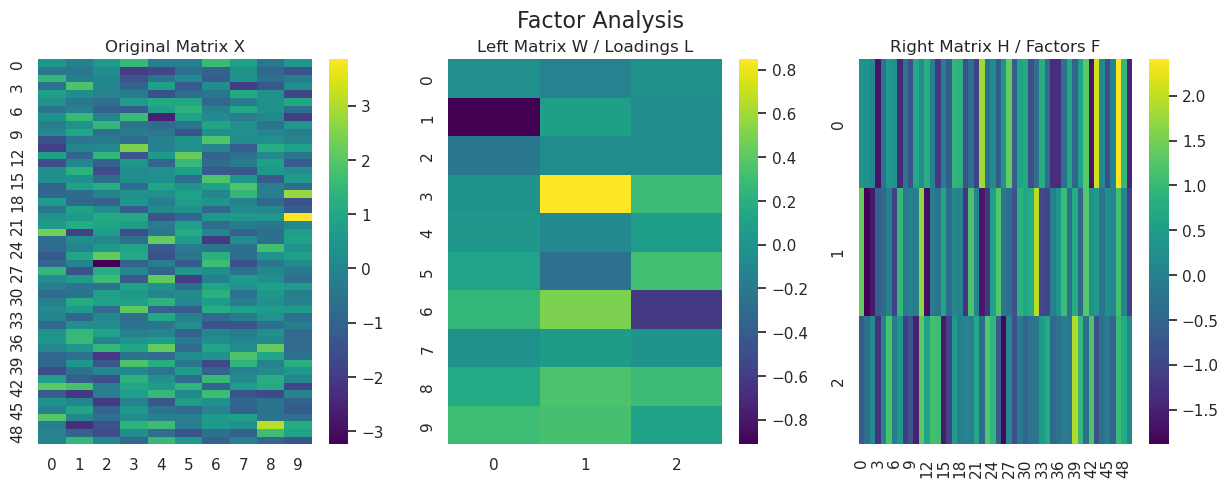

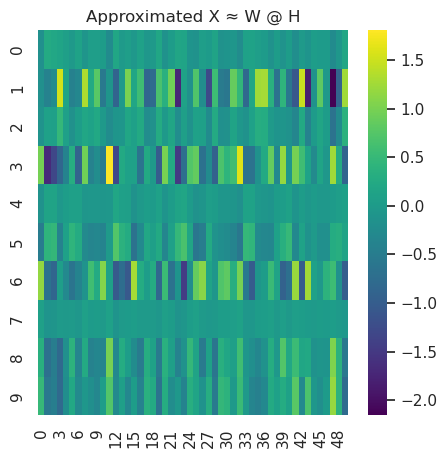

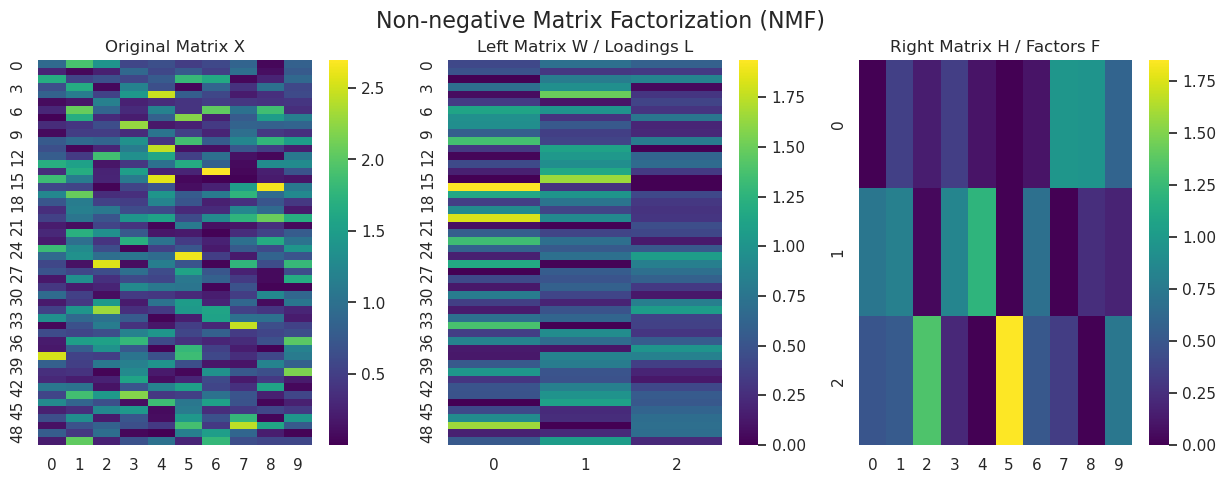

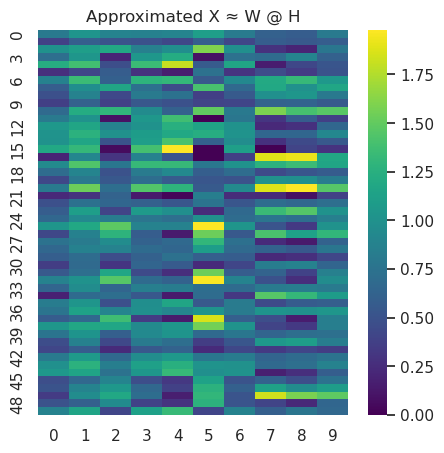

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import FactorAnalysis, NMF

sns.set(style="white")

def visualize_matrix_multiplication(X, W, H, title="Matrix Multiplication"):
    """Visualize how X is approximated by W @ H"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    sns.heatmap(X, ax=axes[0], cmap="viridis", cbar=True)
    axes[0].set_title("Original Matrix X")
    
    sns.heatmap(W, ax=axes[1], cmap="viridis", cbar=True)
    axes[1].set_title("Left Matrix W / Loadings L")
    
    sns.heatmap(H, ax=axes[2], cmap="viridis", cbar=True)
    axes[2].set_title("Right Matrix H / Factors F")
    
    plt.suptitle(title, fontsize=16)
    plt.show()
    
    # Visualize the multiplication result
    X_approx = W @ H
    plt.figure(figsize=(5,5))
    sns.heatmap(X_approx, cmap="viridis", cbar=True)
    plt.title(f"Approximated X ≈ W @ H")
    plt.show()

# -----------------------------
# Example for Factor Analysis
# -----------------------------
np.random.seed(42)
n_samples, n_features, n_factors = 50, 10, 3

# Generate synthetic data
X = np.random.randn(n_samples, n_features)

fa = FactorAnalysis(n_components=n_factors, random_state=42)
X_fa = fa.fit_transform(X)        # Factor scores (F)
L = fa.components_.T               # Loadings matrix (L)

visualize_matrix_multiplication(X, L, X_fa.T, title="Factor Analysis")

# -----------------------------
# Example for NMF
# -----------------------------
X_nmf = np.abs(np.random.randn(n_samples, n_features))  # NMF requires non-negative
nmf = NMF(n_components=n_factors, init="random", random_state=42, max_iter=500)
W = nmf.fit_transform(X_nmf)
H = nmf.components_

visualize_matrix_multiplication(X_nmf, W, H, title="Non-negative Matrix Factorization (NMF)")


In [64]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyArrowPatch

def plot_dfa_lambda_duplicated_arrows(
    Lambda,
    F_seq,          # (T, K, N)
    sigma=0.3,
    title=r"Dynamic Factor Analysis"
):
    """
    DFA visualization with:
    - Lambda duplicated across time steps
    - Equation rendered inside the figure
    - Downward arrows indicating time ordering
    """
    T, K, N = F_seq.shape
    D, K2 = Lambda.shape
    assert K == K2

    # Generate data
    eps_seq = sigma * np.random.randn(T, D, N)
    X_seq = np.einsum("dk,tkn->tdn", Lambda, F_seq) + eps_seq

    # Shared color scale
    vmax = np.max(np.abs(
        np.concatenate([
            Lambda.flatten(),
            F_seq.flatten(),
            eps_seq.flatten(),
            X_seq.flatten()
        ])
    ))
    cmap = plt.cm.bwr

    # Layout: [Lambda | × | F_t | + | eps_t | = | X_t]
    fig = plt.figure(figsize=(18, 3.2 * T))
    gs = GridSpec(
        T, 7,
        width_ratios=[1.2, 0.25, 1, 0.25, 1, 0.25, 1],
        hspace=0.35
    )

    def draw(ax, M, label):
        im = ax.imshow(M, cmap=cmap, vmin=-vmax, vmax=vmax, aspect="auto")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(label, fontsize=11)
        return im

    axes_lambda = []

    # Draw rows
    for t in range(T):
        ax_X   = fig.add_subplot(gs[t, 0])
        ax_L   = fig.add_subplot(gs[t, 2])
        ax_F   = fig.add_subplot(gs[t, 4])
        ax_eps = fig.add_subplot(gs[t, 6])
       
        draw(ax_X,   X_seq[t], rf"$X_{{{t}}}$ (D x N)")
        draw(ax_L,   Lambda,        r"$\Lambda$ (D x K)")
        draw(ax_F,   F_seq[t],      rf"$F_{{{t}}}$ (K x N)")
        im =  draw(ax_eps, eps_seq[t],    rf"$\varepsilon_{{{t}}}$ (D x N)")

        ax_X.set_ylabel(f"t = {t}", fontsize=11)
        axes_lambda.append(ax_X)

        # Equation operators (draw only once per row)
        for col, symbol in zip([1, 3, 5], [r"$=$", r"$\times$", r"$+$"]):
            ax_op = fig.add_subplot(gs[t, col])
            ax_op.axis("off")
            ax_op.text(
                0.5, 0.5, symbol,
                fontsize=22,
                ha="center",
                va="center"
            )

    # --- Time arrows (downward) ---
    for t in range(T - 1):
        ax_top = axes_lambda[t]
        ax_bottom = axes_lambda[t + 1]

        # Arrow start at bottom of top cell, end at top of bottom cell
        pos_top = ax_top.get_position()
        pos_bottom = ax_bottom.get_position()

        x = pos_top.x0 - 0.05  # left of Lambda column
        y_start = pos_top.y0
        y_end = pos_bottom.y1

        arrow = FancyArrowPatch(
            (x, y_start),
            (x, y_end),
            transform=fig.transFigure,
            arrowstyle="-|>",   # better head
            mutation_scale=20, # bigger arrow head
            linewidth=2,
            color="black",
            alpha=0.9
        )
        fig.add_artist(arrow)

        # Optional label
        fig.text(
            x - 0.02,
            0.5 * (y_start + y_end),
            r"$t+1$",
            rotation=90,
            fontsize=10,
            va="center",
            ha="center"
        )

    # Global colorbar
    fig.colorbar(im, ax=fig.axes, shrink=0.7)

    fig.suptitle(
        title + r":  $X_t = \Lambda F_t + \varepsilon_t$",
        fontsize=16,
        fontweight="bold"
    )

    plt.show()


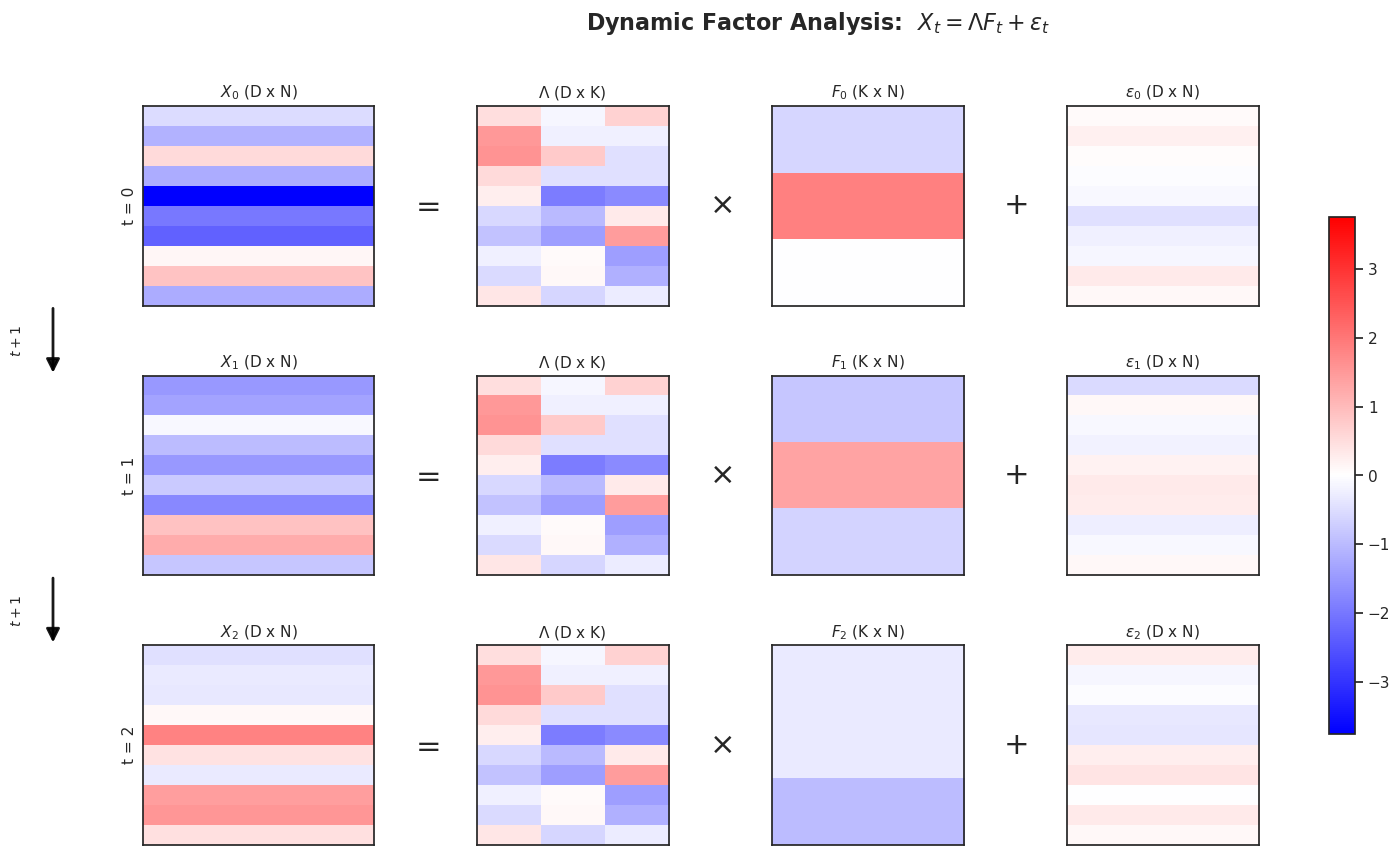

In [65]:
np.random.seed(42)

D, K, N = 10, 3, 1
T = 3

Lambda = np.random.randn(D, K)

# Simple temporal dynamics (random walk)
F_seq = np.zeros((T, K, N))
F_seq[0] = np.random.randn(K, N)
for t in range(1, T):
    F_seq[t] = 0.5 * F_seq[t-1] + 0.5 * np.random.randn(K, N)

plot_dfa_lambda_duplicated_arrows(Lambda, F_seq)


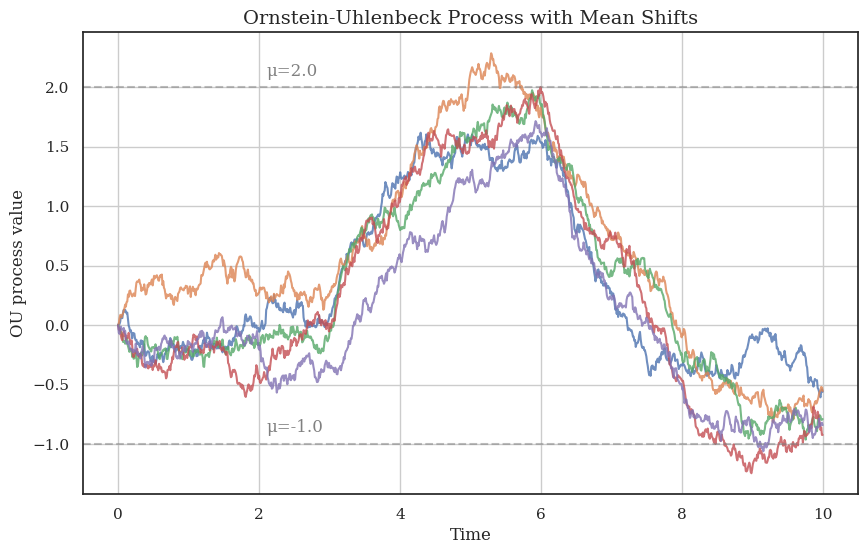

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['text.usetex'] = False  # disable LaTeX rendering


def simulate_ou_mean_shift(
    theta=0.7,      # speed of mean reversion
    sigma=0.3,      # volatility
    x0=0.0,         # initial value
    T=10,           # total time
    dt=0.01,        # time step
    mean_schedule=None  # list of tuples (time, new_mean)
):
    """
    Simulate an OU process with mean shifting.
    mean_schedule: list of (t_shift, mu_shift) tuples
    """
    n_steps = int(T/dt)
    x = np.zeros(n_steps)
    t = np.linspace(0, T, n_steps)
    x[0] = x0
    
    # default: mean 0
    mu = 0.0
    mean_idx = 0
    
    if mean_schedule is None:
        mean_schedule = []
    
    for i in range(1, n_steps):
        # Check if we need to shift mean
        if mean_idx < len(mean_schedule) and t[i] >= mean_schedule[mean_idx][0]:
            mu = mean_schedule[mean_idx][1]
            mean_idx += 1
        
        # OU update
        dx = theta * (mu - x[i-1]) * dt + sigma * np.sqrt(dt) * np.random.randn()
        x[i] = x[i-1] + dx
        
    return t, x

# ---------------------------
# Visualization
# ---------------------------
np.random.seed(42)
n_traj = 5
mean_schedule = [(3, 2.0), (6, -1.0)]  # shift mean at t=3 to 2, at t=6 to -1

plt.figure(figsize=(10, 6))
for _ in range(n_traj):
    t, x = simulate_ou_mean_shift(mean_schedule=mean_schedule)
    plt.plot(t, x, alpha=0.8)

# plot the mean shifts
for t_shift, mu_shift in mean_schedule:
    plt.axhline(mu_shift, linestyle='--', color='gray', alpha=0.5)
    plt.text(T-0.9, mu_shift+0.1, f"μ={mu_shift}", color='gray')

plt.xlabel("Time")
plt.ylabel("OU process value")
plt.title("Ornstein-Uhlenbeck Process with Mean Shifts")
plt.grid(True)
plt.show()


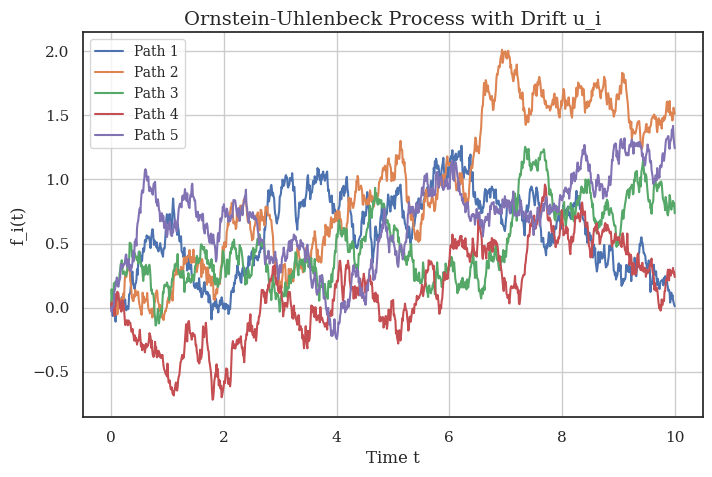

In [72]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# OU process parameters
# --------------------------
T = 10.0          # total time
dt = 0.01         # time step
n_steps = int(T / dt)
n_paths = 5       # number of trajectories to simulate

p = 1             # dimension of f_i(t)
Theta = -0.5      # drift coefficient
Q = 0.2           # diffusion coefficient

# control term u_i = H s_i + gamma
H = 0.3
s_i = 1.0
gamma = 0.1
u_i = H * s_i + gamma

# --------------------------
# Simulate OU process
# --------------------------
t = np.linspace(0, T, n_steps)
f = np.zeros((n_paths, n_steps))
f[:, 0] = 0.0  # initial condition f_i(0) ~ p0 = 0

for i in range(n_steps - 1):
    dW = np.random.normal(scale=np.sqrt(dt), size=n_paths)  # Wiener increments
    f[:, i+1] = f[:, i] + (Theta * f[:, i] + u_i) * dt + np.sqrt(Q) * dW

# --------------------------
# Plot
# --------------------------
plt.figure(figsize=(8,5))
for i in range(n_paths):
    plt.plot(t, f[i], label=f'Path {i+1}')
plt.xlabel('Time t')
plt.ylabel('f_i(t)')
plt.title('Ornstein-Uhlenbeck Process with Drift u_i')
plt.grid(True)
plt.legend()
plt.show()


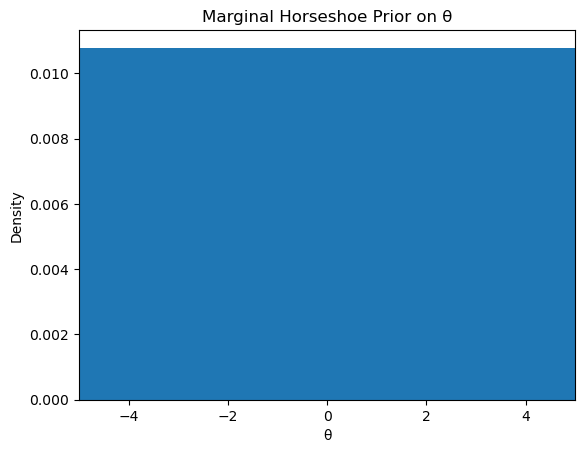

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

N = 200_000

# Half-Cauchy via absolute value of Cauchy
lambda_samples = np.abs(np.random.standard_cauchy(N))

# Horseshoe coefficients
theta = np.random.normal(0, lambda_samples)

# Plot
plt.figure()
plt.hist(theta, bins=2000, density=True)
plt.xlim(-5, 5)
plt.title("Marginal Horseshoe Prior on θ")
plt.xlabel("θ")
plt.ylabel("Density")
plt.show()


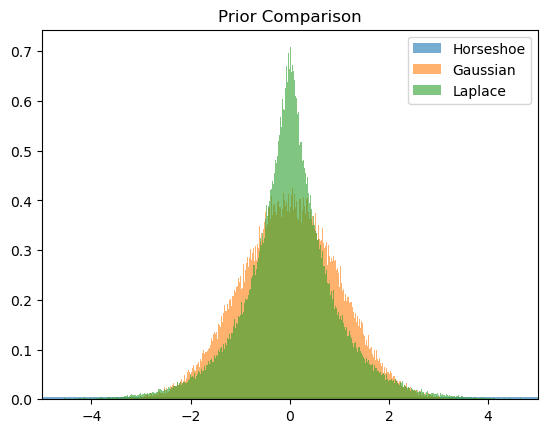

In [2]:
theta_gaussian = np.random.normal(0, 1, N)
theta_laplace = np.random.laplace(0, 1/np.sqrt(2), N)

plt.figure()
plt.hist(theta, bins=1000, density=True, alpha=0.6, label="Horseshoe")
plt.hist(theta_gaussian, bins=1000, density=True, alpha=0.6, label="Gaussian")
plt.hist(theta_laplace, bins=1000, density=True, alpha=0.6, label="Laplace")
plt.xlim(-5, 5)
plt.legend()
plt.title("Prior Comparison")
plt.show()


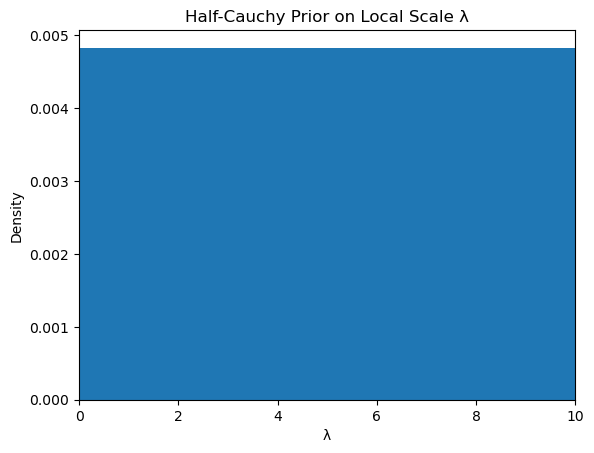

In [3]:
plt.figure()
plt.hist(lambda_samples, bins=1000, density=True)
plt.xlim(0, 10)
plt.title("Half-Cauchy Prior on Local Scale λ")
plt.xlabel("λ")
plt.ylabel("Density")
plt.show()


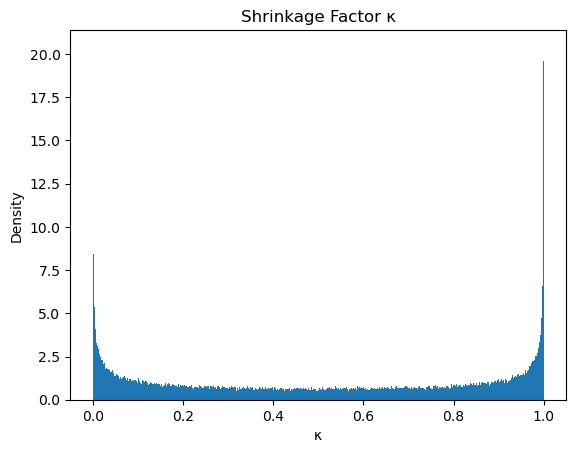

In [4]:
kappa = 1 / (1 + lambda_samples**2)

plt.figure()
plt.hist(kappa, bins=1000, density=True)
plt.title("Shrinkage Factor κ")
plt.xlabel("κ")
plt.ylabel("Density")
plt.show()


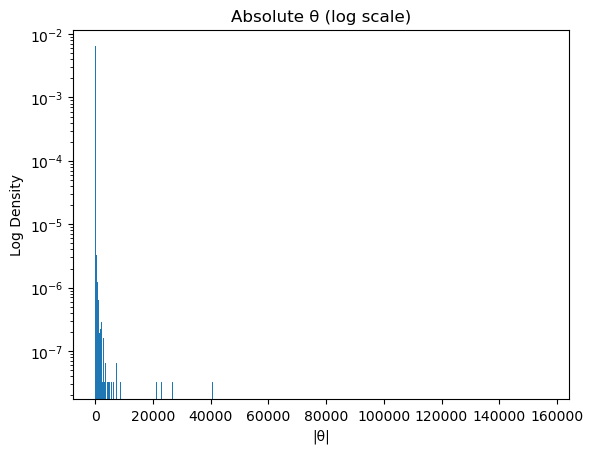

In [5]:
plt.figure()
plt.hist(np.abs(theta), bins=1000, density=True, log=True)
plt.title("Absolute θ (log scale)")
plt.xlabel("|θ|")
plt.ylabel("Log Density")
plt.show()


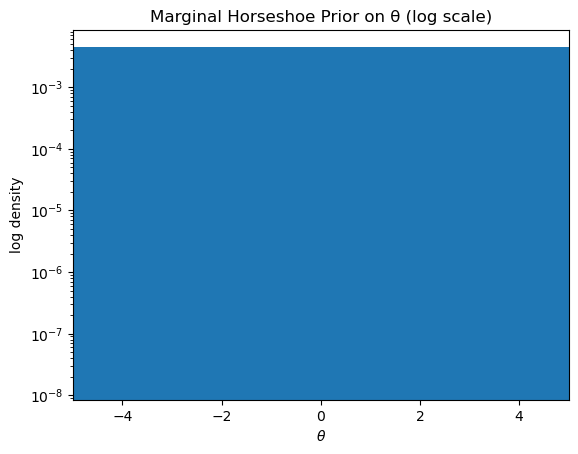

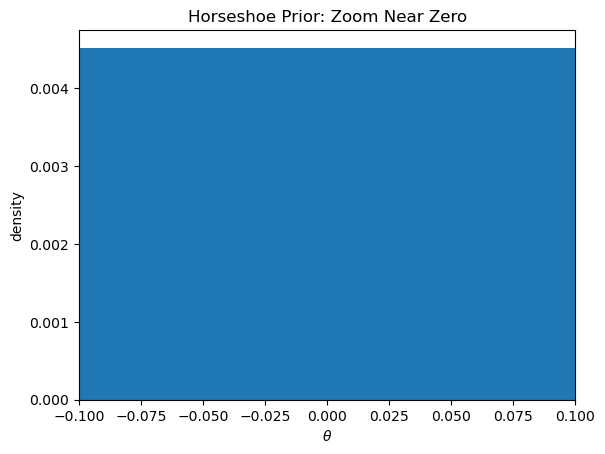

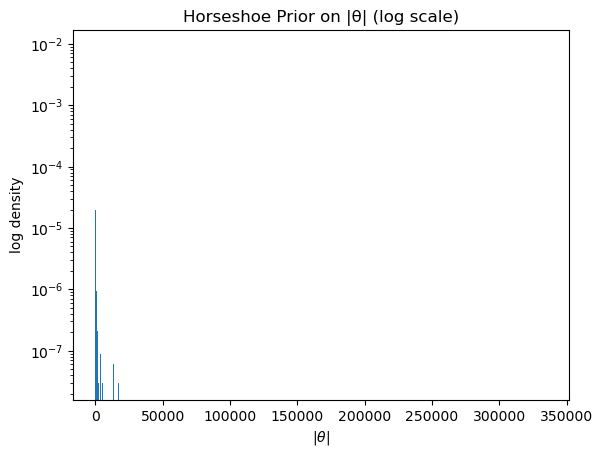

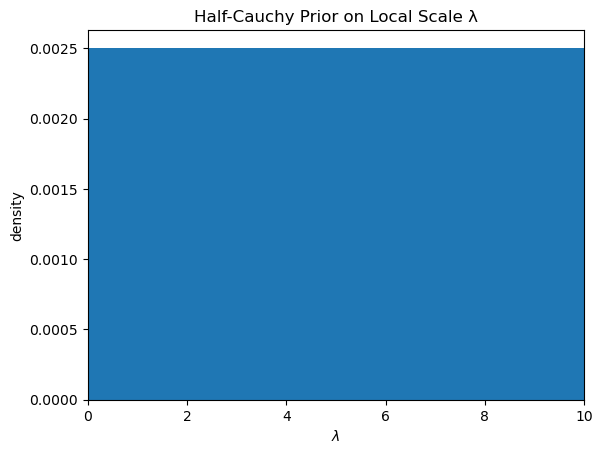

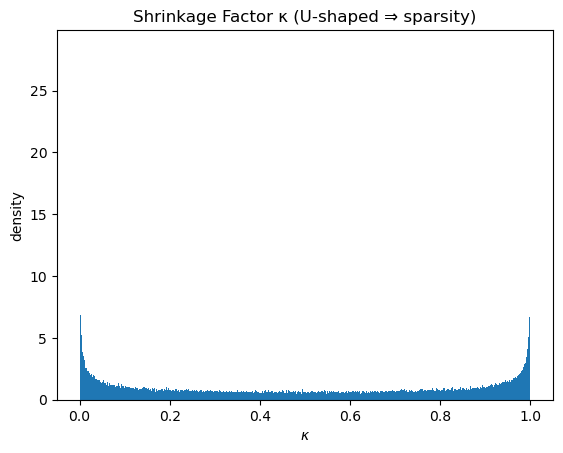

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Reproducibility
# ----------------------------
np.random.seed(42)

# ----------------------------
# Sample from Horseshoe prior
# θ | λ ~ N(0, λ^2)
# λ ~ Half-Cauchy(0, 1)
# ----------------------------
N = 300_000

# Half-Cauchy via abs(Cauchy)
lambda_samples = np.abs(np.random.standard_cauchy(N))

# Horseshoe coefficients
theta = np.random.normal(0.0, lambda_samples)

# ----------------------------
# 1) Marginal horseshoe prior (log density)
# ----------------------------
plt.figure()
plt.hist(theta, bins=3000, density=True, log=True)
plt.xlim(-5, 5)
plt.xlabel(r"$\theta$")
plt.ylabel("log density")
plt.title("Marginal Horseshoe Prior on θ (log scale)")
plt.show()

# ----------------------------
# 2) Zoom near zero (see spike)
# ----------------------------
plt.figure()
plt.hist(theta, bins=3000, density=True)
plt.xlim(-0.1, 0.1)
plt.xlabel(r"$\theta$")
plt.ylabel("density")
plt.title("Horseshoe Prior: Zoom Near Zero")
plt.show()

# ----------------------------
# 3) Absolute value (cleaner view)
# ----------------------------
plt.figure()
plt.hist(np.abs(theta), bins=3000, density=True, log=True)
plt.xlabel(r"$|\theta|$")
plt.ylabel("log density")
plt.title("Horseshoe Prior on |θ| (log scale)")
plt.show()

# ----------------------------
# 4) Local scale λ (Half-Cauchy)
# ----------------------------
plt.figure()
plt.hist(lambda_samples, bins=3000, density=True)
plt.xlim(0, 10)
plt.xlabel(r"$\lambda$")
plt.ylabel("density")
plt.title("Half-Cauchy Prior on Local Scale λ")
plt.show()

# ----------------------------
# 5) Shrinkage factor κ = 1 / (1 + λ^2)
# ----------------------------
kappa = 1.0 / (1.0 + lambda_samples**2)

plt.figure()
plt.hist(kappa, bins=2000, density=True)
plt.xlabel(r"$\kappa$")
plt.ylabel("density")
plt.title("Shrinkage Factor κ (U-shaped ⇒ sparsity)")
plt.show()
